# **Bank Fraud Detection** 

This project focuses on detecting fraudulent financial transactions using a large-scale dataset containing over **6.3 million transaction records**. The objective is to build a machine learning model that can accurately identify fraudulent transactions and help financial institutions reduce losses caused by fraud.

#### **Dataset Information:** 
The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)

**Columns:**

1. step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 
   (30 days simulation).
2. type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
3. amount - amount of the transaction in local currency.
4. nameOrig - customer who started the transaction
5. oldbalanceOrg - initial balance before the transaction
6. newbalanceOrig - new balance after the transaction
7. nameDest - customer who is the recipient of the transaction
8. oldbalanceDest - initial balance recipient before the transaction. Note that there is not 
   information for customers that start with M (Merchants).
9. newbalanceDest - new balance recipient after the transaction. Note that there is not information for 
   customers that start with M (Merchants).
10. isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this 
    specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.
11. isFlaggedFraud - The business model aims to control massive transfers from one account to another 
    and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

**LINK**: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download

## Import Libraries & Configuration

In [1]:
# Data manipulation and visualization 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier

# Performance metrices  
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve, precision_recall_curve

# Hyperparameter Tuning 
from sklearn.model_selection import RandomizedSearchCV

# Save model 
import joblib 

# Visualization configuration
sns.set_style('darkgrid')
plt.rcParams["figure.figsize"] = (6, 4)

## Load Dataset

In [2]:
# Load the dataset 
df = pd.read_csv('../data/fraud_data.csv')

In [4]:
df['type'].unique()

<ArrowStringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

## Exploratory Data Analysis (EDA)

In [20]:
# Check sample dataset 
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df['newbalanceDest'].max()

np.float64(356179278.92)

In [4]:
# Check shape of the dataset 
print(f"Number of Rows: {df.shape[0]}")    
print(f"Number of Columns: {df.shape[1]}")    

Number of Rows: 6362620
Number of Columns: 11


In [5]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
# Check statistical summary 
df.describe().astype(int).T

,count,mean,std,min,25%,50%,75%,max
step,6362620,243,142,1,156,239,335,743
amount,6362620,179861,603858,0,13389,74871,208721,92445516
oldbalanceOrg,6362620,833883,2888242,0,0,14208,107315,59585040
newbalanceOrig,6362620,855113,2924048,0,0,0,144258,49585040
oldbalanceDest,6362620,1100701,3399180,0,0,132705,943036,356015889
newbalanceDest,6362620,1224996,3674128,0,0,214661,1111909,356179278
isFraud,6362620,0,0,0,0,0,0,1
isFlaggedFraud,6362620,0,0,0,0,0,0,1


In [7]:
# Check missing values 
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
# Check duplicate values 
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check type, isFraud and isFlaggedFraud total values 
print(df['type'].value_counts())
print("-"*40)
print(df['isFraud'].value_counts())
print("-"*40)
print(df['isFlaggedFraud'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
----------------------------------------
isFraud
0    6354407
1       8213
Name: count, dtype: int64
----------------------------------------
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [10]:
# Check fraud ratio
print(f"Non-Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[0]*100,4)}%")
print(f"Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[1]*100,4)}%")

Non-Fraud Ratio: 99.8709%
Fraud Ratio: 0.1291%


In [11]:
# Check flagged fraud ratio
print(f"Flagged Fraud Ratio: {round(df['isFlaggedFraud'].value_counts(normalize=True)[1]*100,4)}%")

Flagged Fraud Ratio: 0.0003%


#### Observation: 
- The dataset contains **6362620 Rows** and **11 Columns** .
- There is no any missing and duplicate value in this dataset.
- Total transactions: **6362620**
- Total normal transactions: **6354407**
- Total fraud transactions: **8213** 
- Overall fraud transactions rate:  0.1291%
- Overall flagged fraud transactions rate: 0.0003%
- The dataset is highly imbalanced.
- Balance-related features (**oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest**) contain many zero values. 
- There is skewness in some columns refers to outliers.

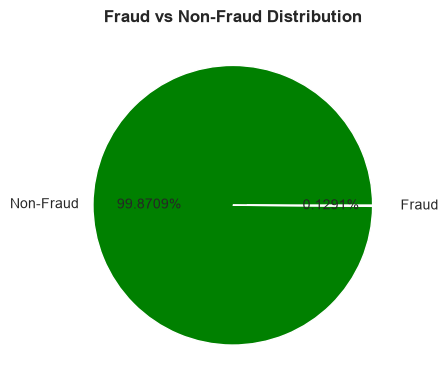

In [4]:
# Fraud vs Non_Fraud Distribution 
fraud_ratio = round(df['isFraud'].value_counts(normalize=True)*100,4)

plt.pie(fraud_ratio,labels=['Non-Fraud','Fraud'],colors=['green', 'red'],autopct='%1.4f%%',explode=(0,0.10))
plt.title('Fraud vs Non-Fraud Distribution', fontweight='bold')
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Fraud_vs_NonFraud_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

While approximately **0.13%** Of transactions are truly fraudulent, the existing rule based system flags less than **0.001%** of transactions, including that most frudulent activity goes **undetected**.

type
CASH_OUT    35.17
PAYMENT     33.81
CASH_IN     21.99
TRANSFER     8.38
DEBIT        0.65
Name: proportion, dtype: float64


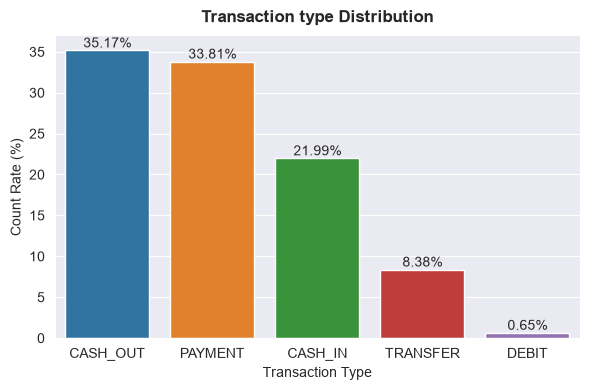

In [13]:
# Check transaction type percentage 
type_percentage = round(df['type'].value_counts(normalize=True)*100,2)
print(type_percentage)

ax = sns.barplot(x=type_percentage.index,y=type_percentage.values,palette='tab10')

plt.title('Transaction type Distribution',fontweight='bold',pad=10)
plt.xlabel('Transaction Type')
plt.ylabel('Count Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')
    
sns.despine() 
plt.tight_layout()
plt.show()

type
TRANSFER    0.77
CASH_OUT    0.18
CASH_IN     0.00
DEBIT       0.00
PAYMENT     0.00
Name: isFraud, dtype: float64


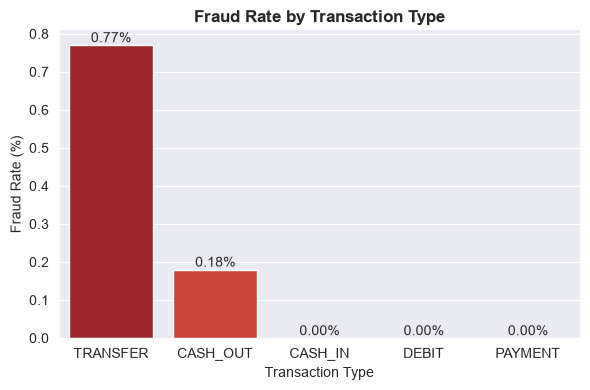

In [5]:
# Check fraud rate by transaction type 
fraud_by_type = round(df.groupby('type')['isFraud'].mean().sort_values(ascending=False)*100,2)
print(fraud_by_type)

ax = sns.barplot( x=fraud_by_type.index,y=fraud_by_type.values,palette='Reds_r')

plt.title('Fraud Rate by Transaction Type', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')

sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Fraud_rate_by_Type.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64


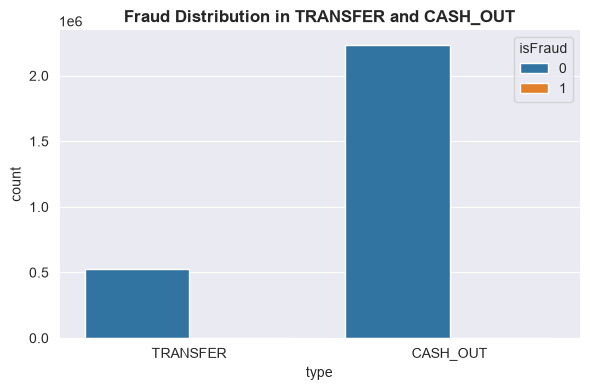

In [6]:
# Check fraud distribution in TRANSFER and CASH_OUT
farud_transaction_type = df[df['type'].isin(['TRANSFER','CASH_OUT'])]
print(farud_transaction_type['type'].value_counts())

sns.countplot(data=farud_transaction_type,x='type',hue='isFraud')
plt.title('Fraud Distribution in TRANSFER and CASH_OUT', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

#### Observation: 
- This dataset is dominated by **CASH_OUT, PAYMENT, and CASH_IN**
- Fraud occurs only in **TRANSFER** and **CASH_OUT** type of transactions. 
- **TRANSFER** has the highest fraud rate - **(77%)**
- **CASH_OUT** has lower fraud rate - **(18%)**
- **PAYMENT**, **CASH_IN**, and **DEBIT** have 0 fraudulent transactions.
- From this insight it looking like **Fraudsters first transfer money to another account and then cash it out**. This aligns with the dataset description.

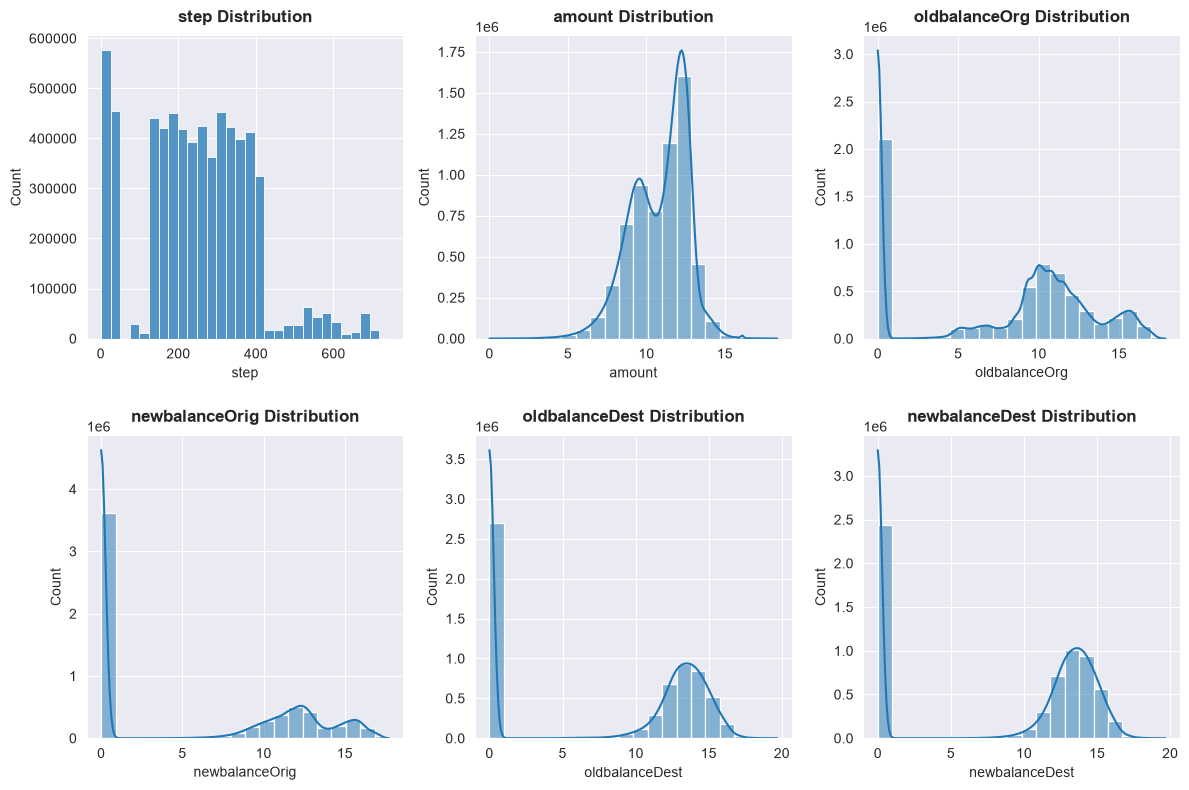

In [3]:
# Check numerical columns distribution
numerical_columns = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 3, i)

    if col=='step': 
        sns.histplot(data=df,x=col,bins=30)
    else: 
        sns.histplot(np.log1p(df[col]),bins=20,kde=True)

    plt.title(f'{col} Distribution', fontweight='bold', pad=10)
    plt.xlabel(col)
    plt.ylabel('Count')
    sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Numerical_Column_Distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

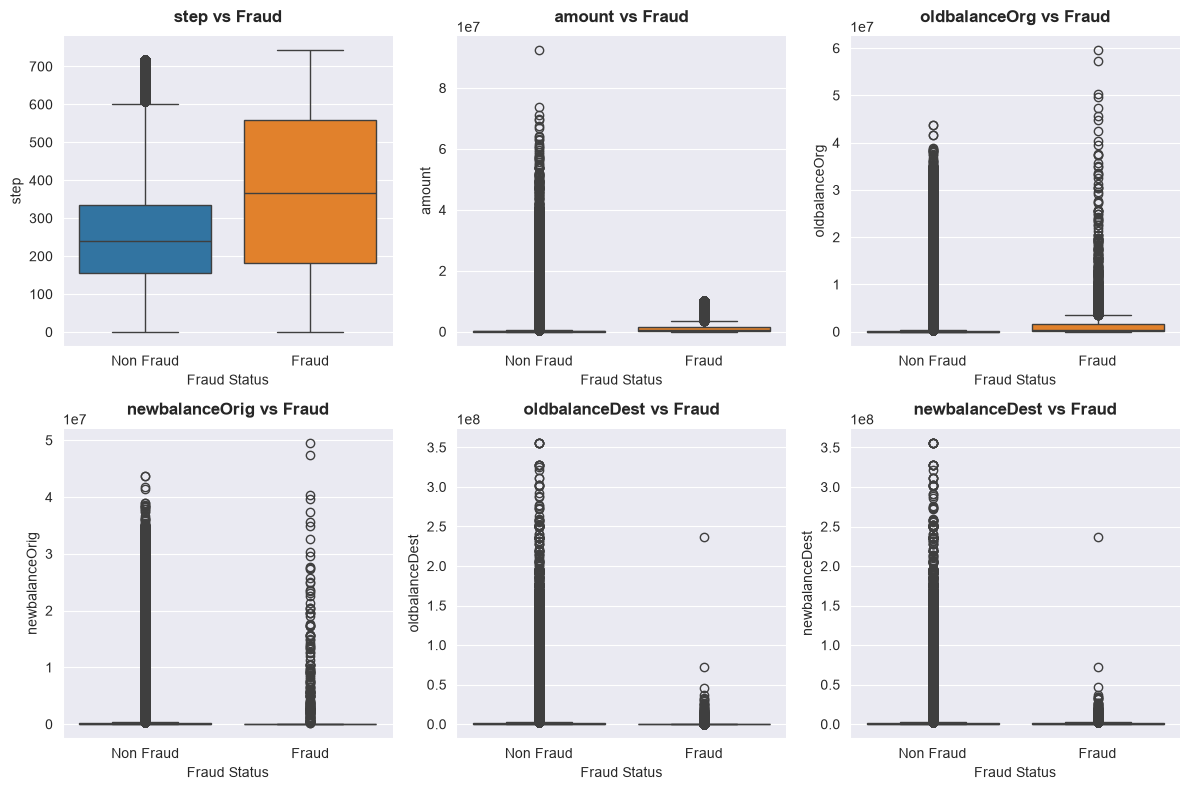

In [5]:
# Compare the distribution between fraud and non-fraud transactions
plt.figure(figsize=(12,8))

for i,col in enumerate(numerical_columns,1):
    plt.subplot(2,3,i)

    sns.boxplot(
        data=df,
        x='isFraud',
        y=col,
        palette='tab10'
    )

    plt.title(f'{col} vs Fraud', fontweight='bold', pad=10)
    plt.xlabel('Fraud Status')
    plt.ylabel(col)
    plt.xticks([0,1],['Non Fraud','Fraud'])
    sns.despine()

plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Columns_vs_Fraud_Check.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
# Create a new DataFrame for step(time) analysis 
time_df = pd.DataFrame()

time_df[['step','isFraud']] = df[['step','isFraud']]

time_df['hour'] = time_df['step'] % 24

hourly_stats = time_df.groupby('hour').agg(
    total_transactions = ('isFraud','count'),
    fraud_transactions = ('isFraud','sum'),
    fraud_rate = ('isFraud','mean')
).reset_index()

hourly_stats.head()

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


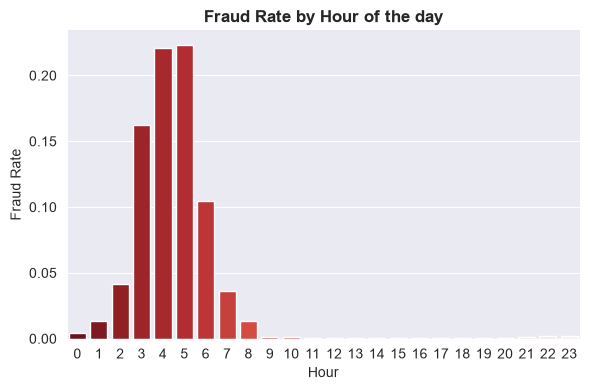

In [9]:
# Check fraud rate by hour 
sns.barplot(data=hourly_stats,x='hour',y='fraud_rate',palette='Reds_r')
plt.title('Fraud Rate by Hour of the day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Fraud_rate_by_hour.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

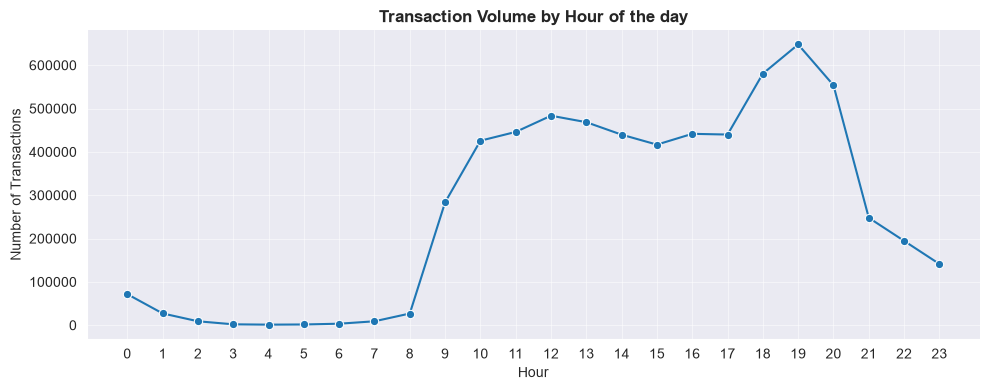

In [ ]:
# Check transaction by hour 
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly_stats,x='hour',y='total_transactions',marker='o')
plt.title('Transaction Volume by Hour of the day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.xticks(range(0,24))
plt.grid(alpha=0.5)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Transaction_Volume_by_Hour.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
# Create is_night to analyse day vs night  
time_df['is_night'] = time_df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
day_night_fraud = (time_df[time_df['isFraud']==1]['is_night'].value_counts(normalize=True).rename({0:'Day',1:'Night'}))
day_night_fraud

is_night
Day      0.674906
Night    0.325094
Name: proportion, dtype: float64

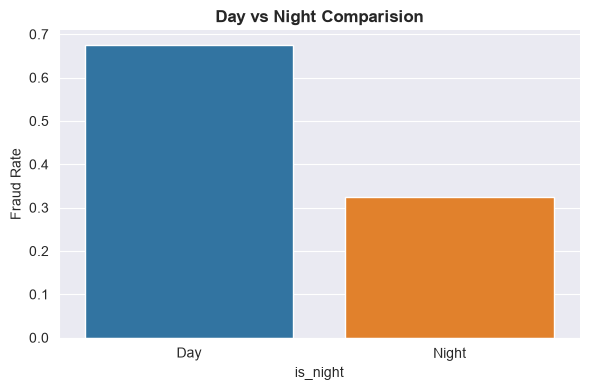

In [12]:
# Check Day vs Night Comparison 
sns.barplot(x=day_night_fraud.index,y=day_night_fraud.values,palette='tab10')
plt.title('Day vs Night Comparision',fontweight='bold')
plt.ylabel('Fraud Rate')
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Day_vs_Night_Comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
# Check top 10 senders customers
top_senders = df[['nameOrig','amount']].sort_values(by='amount',ascending=False).head(10)
top_senders

,nameOrig,amount
3686583,C1715283297,92445516.64
4060598,C2127282686,73823490.36
4146397,C2044643633,71172480.42
3946920,C1425667947,69886731.30
3911956,C1584456031,69337316.27
3937152,C811810230,67500761.29
4105338,C420748282,66761272.21
3892529,C1139847449,64234448.19
3991638,C300140823,63847992.58
4143801,C372535854,63294839.63


In [23]:
# Check top 10 receiver customers 
top_receivers = df[['nameDest','amount']].sort_values(by='amount',ascending=False).head(10)
top_receivers

,nameDest,amount
3686583,C439737079,92445516.64
4060598,C753026640,73823490.36
4146397,C84111522,71172480.42
3946920,C167875008,69886731.30
3911956,C1472140329,69337316.27
3937152,C1757599079,67500761.29
4105338,C1073241084,66761272.21
3892529,C65111466,64234448.19
3991638,C514940761,63847992.58
4143801,C1871605747,63294839.63


In [24]:
# Check sender customers who involved in fraud 
fraud_senders =  df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_senders

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [25]:
# Check receiver customers who involved in fraud 
fraud_receiver =  df[df['isFraud']==1]['nameDest'].value_counts().head(10)
fraud_receiver

nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
C200064275     2
C185805228     2
C52390890      2
C935310781     2
C1827219533    2
Name: count, dtype: int64

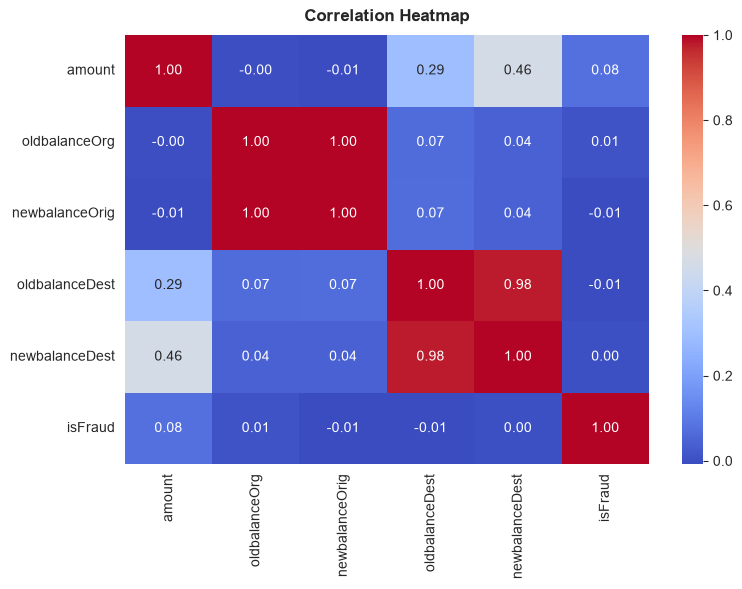

In [13]:
# Check correlations 
plt.figure(figsize=(8,6))
corr_columns = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','isFraud']]
sns.heatmap(corr_columns.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap', fontweight='bold', pad=10)
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Correlation_Heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Observation: 
This corellation matrix reveals severe multicollinearity between pre-transaction and post-transaction balances, indicating redundancy. To address this balance-difference features were engineered and
redundent variables need to be removed, improving model stability and interpretability.

In [4]:
# Make copy of the dataset 
df_copy = df.copy()
df_copy.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Feature Engineering 

In [5]:
# Change in sender account balance
df_copy['balanceDiffOrig'] = df_copy['oldbalanceOrg'] - df_copy['newbalanceOrig']

# Change in receiver's account balance
df_copy['balanceDiffDest'] = df_copy['newbalanceDest'] - df_copy['oldbalanceDest']

# Create hour of the day
df_copy['hour'] = df_copy['step'] % 24

df_copy.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest,hour
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,1


In [6]:
# Drop unnecessary columns 
df_copy = df_copy.drop([
    'step',
    'nameOrig',
    'nameDest',
    'isFlaggedFraud',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
], axis=1)

df_copy.head()

,type,amount,isFraud,balanceDiffOrig,balanceDiffDest,hour
0,PAYMENT,9839.64,0,9839.64,0.0,1
1,PAYMENT,1864.28,0,1864.28,0.0,1
2,TRANSFER,181.00,1,181.00,0.0,1
3,CASH_OUT,181.00,1,181.00,-21182.0,1
4,PAYMENT,11668.14,0,11668.14,0.0,1


In [8]:
# Define Numerical, Categorical and Target Columns

# Target column
target_column = 'isFraud'

# Numerical_columns 
numerical_columns = [col for col  in df_copy.select_dtypes(include=['int64','float64']).columns if col!= target_column]

# Categorical_columns
categorical_columns = df_copy.select_dtypes(include=['object']).columns.to_list()

print("Target Column:")
print(target_column)

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Target Column:
isFraud

Numerical Columns:
['amount', 'balanceDiffOrig', 'balanceDiffDest', 'hour']

Categorical Columns:
['type']


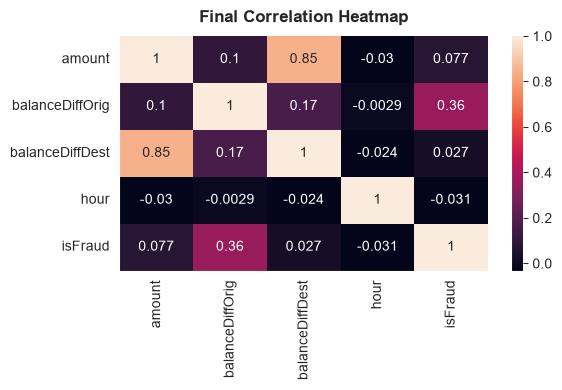

In [18]:
# Check correlation between the final selected features
final_corr = numerical_columns + [target_column]
plt.figure(figsize=(6,4))
sns.heatmap(df_copy[final_corr].corr(),annot=True)
plt.title('Final Correlation Heatmap', fontweight='bold', pad=10)
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Final_Correlation_Heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [10]:
# Separating dependent and independent features 
X = df_copy.drop(target_column,axis=1)
y = df_copy[target_column]

In [11]:
# Check X 
X.head()


,type,amount,balanceDiffOrig,balanceDiffDest,hour
0,PAYMENT,9839.64,9839.64,0.0,1
1,PAYMENT,1864.28,1864.28,0.0,1
2,TRANSFER,181.00,181.00,0.0,1
3,CASH_OUT,181.00,181.00,-21182.0,1
4,PAYMENT,11668.14,11668.14,0.0,1


In [12]:
# Check y 
y

0          0
1          0
2          1
3          1
4          0
          ..
6362615    1
6362616    1
6362617    1
6362618    1
6362619    1
Name: isFraud, Length: 6362620, dtype: int64

## Train Test Split 

In [13]:
# train test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

In [14]:
# Check train shape and test shape 
print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape : (5090096, 5)
Test shape : (1272524, 5)


## Data Preprocessing

#### Build Preprocessing Pipeline

In [15]:
# Numerical pipeline 
numerical_preprocessing = Pipeline([
    ('scaler',StandardScaler())
])

# Categorical pipeline 
categorical_preprocessing = Pipeline([
    ('ohe',OneHotEncoder(drop='first'))
])

#### Build ColumnTransformer

In [16]:
# Column Transformer 
preprocessor = ColumnTransformer([
    ('num',numerical_preprocessing,numerical_columns),
    ('cat',categorical_preprocessing,categorical_columns)
])

## Model Training & Evaluation

In [17]:
# Define models 
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=200,
        max_depth=10,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Create function to evaluate model 
def evaluate_model(true,predicted,proba):
    accuracy = accuracy_score(true,predicted)
    precision = precision_score(true,predicted)
    recall = recall_score(true,predicted)
    f1 = f1_score(true,predicted)
    roc_auc = roc_auc_score(true, proba)

    return accuracy, precision, recall, f1, roc_auc

# Store results
results = []
trained_models = {}

# Train and evaluate model 
for name, model in models.items(): 

    # create pipeline for current model 
    model_pipeline = Pipeline([
        ('preprocessor',preprocessor),
        ('model',model)
    ])

    # fit model 
    model_pipeline.fit(X_train,y_train)

    # predictions for train and test data 
    y_train_pred = model_pipeline.predict(X_train)
    y_test_pred = model_pipeline.predict(X_test)

    y_train_proba = model_pipeline.predict_proba(X_train)[:,1]
    y_test_proba = model_pipeline.predict_proba(X_test)[:,1]

    #Save trained model 
    trained_models[name] = model_pipeline

    # model evaluation for train and test data 
    train_accuracy, train_precision, train_recall, train_f1, train_roc_auc = evaluate_model(y_train, y_train_pred, y_train_proba)
    test_accuracy, test_precision, test_recall, test_f1, test_roc_auc = evaluate_model(y_test, y_test_pred, y_test_proba)

    # Store test results
    results.append({
        "Model": name,
        "Recall": test_recall,
        "F1 Score": test_f1,
        "ROC-AUC": test_roc_auc,    
        "Precision": test_precision,
        "Accuracy": test_accuracy
    })

    # print model and performance metrices 
    print(f"========== {name} ==========")

    print("Model performance for Train data -")
    print(f"Recall : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")
    print(f"ROC-AUC : {train_roc_auc:.4f}")
    print(f"Precision : {train_precision:.4f}")
    print(f"Accuracy : {train_accuracy:.4f}")

    print("-"*40)

    print("Model performance for Test data -")
    print(f"Recall : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")
    print(f"ROC-AUC : {test_roc_auc:.4f}")
    print(f"Precision : {test_precision:.4f}")  
    print(f"Accuracy : {test_accuracy:.4f}")

    print("="*40)
    print("\n")

========== Logistic Regression ==========
Model performance for Train data -
Recall : 0.9499
F1 Score : 0.0493
ROC-AUC : 0.9898
Precision : 0.0253
Accuracy : 0.9528
----------------------------------------
Model performance for Test data -
Recall : 0.9470
F1 Score : 0.0493
ROC-AUC : 0.9904
Precision : 0.0253
Accuracy : 0.9528


========== Decision Tree ==========
Model performance for Train data -
Recall : 0.9886
F1 Score : 0.0622
ROC-AUC : 0.9976
Precision : 0.0321
Accuracy : 0.9615
----------------------------------------
Model performance for Test data -
Recall : 0.9690
F1 Score : 0.0612
ROC-AUC : 0.9880
Precision : 0.0316
Accuracy : 0.9616


========== Random Forest ==========
Model performance for Train data -
Recall : 0.9967
F1 Score : 0.0562
ROC-AUC : 0.9979
Precision : 0.0289
Accuracy : 0.9568
----------------------------------------
Model performance for Test data -
Recall : 0.9836
F1 Score : 0.0556
ROC-AUC : 0.9968
Precision : 0.0286
Accuracy : 0.9568


========== XGBoost ===

In [20]:
# Compare model performance
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['F1 Score', 'ROC-AUC', 'Recall'],ascending=False)
results_df

,Model,Recall,F1 Score,ROC-AUC,Precision,Accuracy
3,XGBoost,0.744979,0.817362,0.959079,0.905325,0.999570
1,Decision Tree,0.968959,0.061177,0.988047,0.031585,0.961602
2,Random Forest,0.983567,0.055551,0.996843,0.028583,0.956819
0,Logistic Regression,0.947048,0.049304,0.990363,0.025311,0.952844


In [22]:
# Select best model 
best_model = results_df.iloc[0]

print(f"Best model: {best_model["Model"]}")
print(f"F1 Score: {best_model["F1 Score"]:.4f}")
print(f"ROC-AUC: {best_model["ROC-AUC"]:.4f}")
print(f"Recall: {best_model["Recall"]:.4f}")
print(f"Precision: {best_model["Precision"]:.4f}")

Best model: XGBoost
F1 Score: 0.8174
ROC-AUC: 0.9591
Recall: 0.7450
Precision: 0.9053


## Hyperparameter Tuning

In [22]:
# Create a model pipeline for best selected model - XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(random_state=42, eval_metric='logloss',tree_method='hist'))
])

# Define parameters for hyperparameter tuning 
params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [10, 50]
}

In [23]:
# Hyperparameter tuning using RandomSearchCV 
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline, 
    param_distributions=params,  
    n_iter=5,   
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6], 'model__min_child_weight': [10, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functi

In [24]:
# Check best score and params 
print("==== Best Score and Params ====")
print("Best Score:",random_search.best_score_)
print("Best Params:",random_search.best_params_)

==== Best Score and Params ====
Best Score: 0.842005932515734
Best Params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}


In [26]:
# Final best estimator 
final_best_xgb = random_search.best_estimator_
final_best_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['type','amount','balanceDiffOrig','balanceDiffDest','hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining col

In [27]:
# Get final predictions 
final_y_pred = final_best_xgb.predict(X_test) 
final_y_proba = final_best_xgb.predict_proba(X_test)[:,1] 

In [30]:
# Final model evaluation 
print(f"Recall : {recall_score(y_test,final_y_pred):.4f}")
print(f"Precision : {precision_score(y_test,final_y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,final_y_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test,final_y_proba):.4f}")

Recall : 0.7645
Precision : 0.9508
F1 Score : 0.8475
ROC-AUC : 0.9956


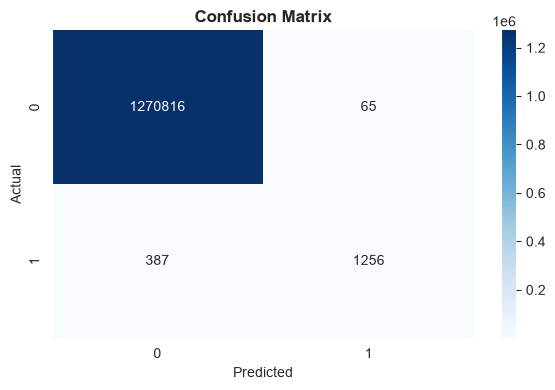

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test,final_y_pred) 

plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig(
    '../plots/Confusion_Matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [39]:
# Classification Report 
print(classification_report(y_test,final_y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.95      0.76      0.85      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.88      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



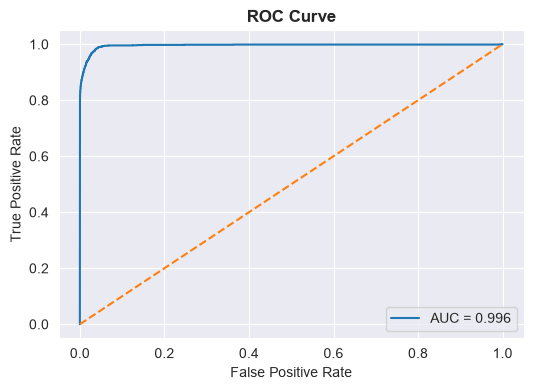

In [43]:
# ROC Curve 
fpr, tpr, thresholds = roc_curve(y_test, final_y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f'AUC = {roc_auc_score(y_test,final_y_proba):.3f}'
)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()

# Save figure
plt.savefig(
    '../plots/ROC_Curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

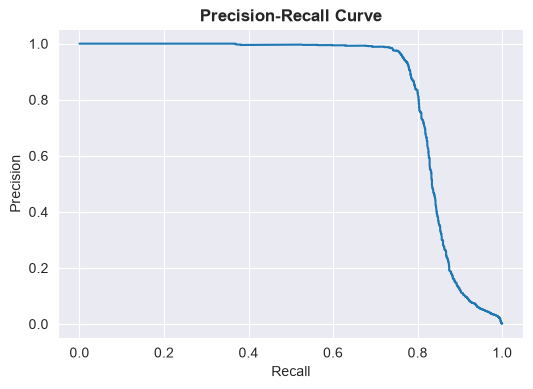

In [ ]:
# Precision Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test,final_y_proba)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
sns.despine()

# Save figure
plt.savefig(
    '../plots/Precision_Recall_Curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [12]:
# Save the model and preprocessor 
joblib.dump(final_best_xgb, '../artifacts/model.pkl')

NameError: name 'final_best_xgb' is not defined

The final XGBoost model achieved a strong balance between fraud detection and false positive reduction.

Out of 1,643 fraudulent transactions, the model successfully detected 1,256 while missing 387. Among more than 1.27 million legitimate transactions, only 65 were incorrectly flagged as fraud.

The model achieved:

- Recall: 76.45%
- Precision: 95.08%
- F1 Score: 84.75%
- ROC-AUC: 99.56%

These results indicate that the model can reliably identify fraudulent activities while minimizing unnecessary alerts. Such a balance is critical in real-world banking systems, where excessive false positives increase operational costs and negatively impact customer experience.

The model can serve as a strong foundation for deployment in a production fraud detection pipeline using FastAPI and Streamlit.